# Week 6 - Deep Learning: Image Denoising with Autoencoder

Building a deep learning model that removes noise from MNIST images using an autoencoder.

In [56]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import os

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.15.0


## Load MNIST Dataset
Download from Kaggle and load the handwritten digit images.

In [57]:
path = kagglehub.dataset_download("awsaf49/mnist-dataset")

from tensorflow.keras.preprocessing.image import load_img, img_to_array

def load_data(base_path, split='training'):
    images, labels = [], []
    split_path = os.path.join(base_path, 'mnist_png', split)
    for digit in sorted(os.listdir(split_path)):
        for fname in os.listdir(os.path.join(split_path, digit)):
            if not fname.endswith('.png'): continue
            img = load_img(os.path.join(split_path, digit, fname), color_mode='grayscale', target_size=(28, 28))
            arr = img_to_array(img).astype('float32').reshape(-1) / 255.0
            images.append(arr)
            labels.append(int(digit))
    return np.array(images), np.array(labels)

x_train, y_train = load_data(path, 'training')
x_test, y_test = load_data(path, 'testing')

# Use subset for faster training
x_train = x_train[:10000]
x_test = x_test[:2000]

print(f'Train: {x_train.shape}, Test: {x_test.shape}')

Train: (10000, 784), Test: (2000, 784)


## Add Noise
Add Gaussian noise to create input-target pairs for training.

In [58]:
def add_noise(images, std=0.15):
    noisy = images + np.random.normal(0, std, images.shape)
    return np.clip(noisy, 0.0, 1.0)

x_train_noisy = add_noise(x_train)
x_test_noisy = add_noise(x_test)
print(f'Noisy train shape: {x_train_noisy.shape}')

Noisy train shape: (10000, 784)


## Build Autoencoder
Encoder compresses 784->128, decoder reconstructs 128->784.

In [59]:
model = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(784, activation='sigmoid')
], name='autoencoder')

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_20 (Dense)            (None, 256)               200960    
                                                                 
 dense_21 (Dense)            (None, 128)               32896     
                                                                 
 dense_22 (Dense)            (None, 256)               33024     
                                                                 
 dense_23 (Dense)            (None, 784)               201488    
                                                                 
Total params: 468368 (1.79 MB)
Trainable params: 468368 (1.79 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## Train the Model

Epoch 1/5
79/79 [==============================] - 2s 10ms/step - loss: 0.0668 - val_loss: 0.0318
Epoch 2/5
79/79 [==============================] - 1s 8ms/step - loss: 0.0293 - val_loss: 0.0211
Epoch 3/5
79/79 [==============================] - 1s 8ms/step - loss: 0.0206 - val_loss: 0.0157
Epoch 4/5
79/79 [==============================] - 1s 8ms/step - loss: 0.0158 - val_loss: 0.0126
Epoch 5/5
79/79 [==============================] - 1s 7ms/step - loss: 0.0132 - val_loss: 0.0108


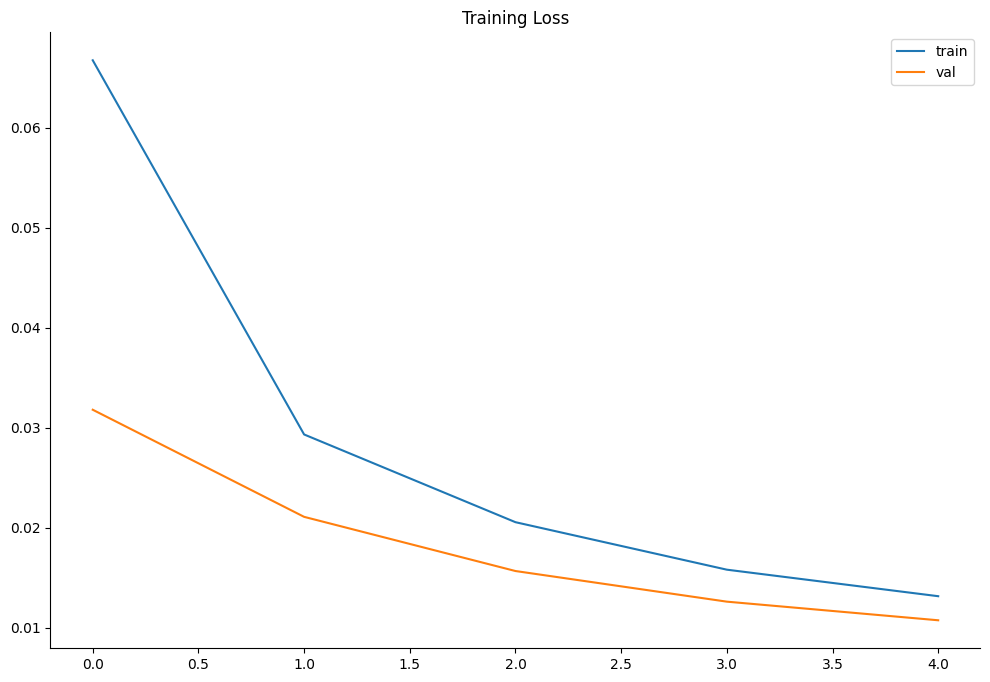

In [60]:
history = model.fit(
    x_train_noisy, x_train,
    epochs=5,
    batch_size=128,
    validation_data=(x_test_noisy, x_test),
    verbose=1
)

# Plot loss
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title('Training Loss')
plt.show()

## Results
Compare original, noisy, and denoised images.

1/1 [==============================] - 0s 84ms/step


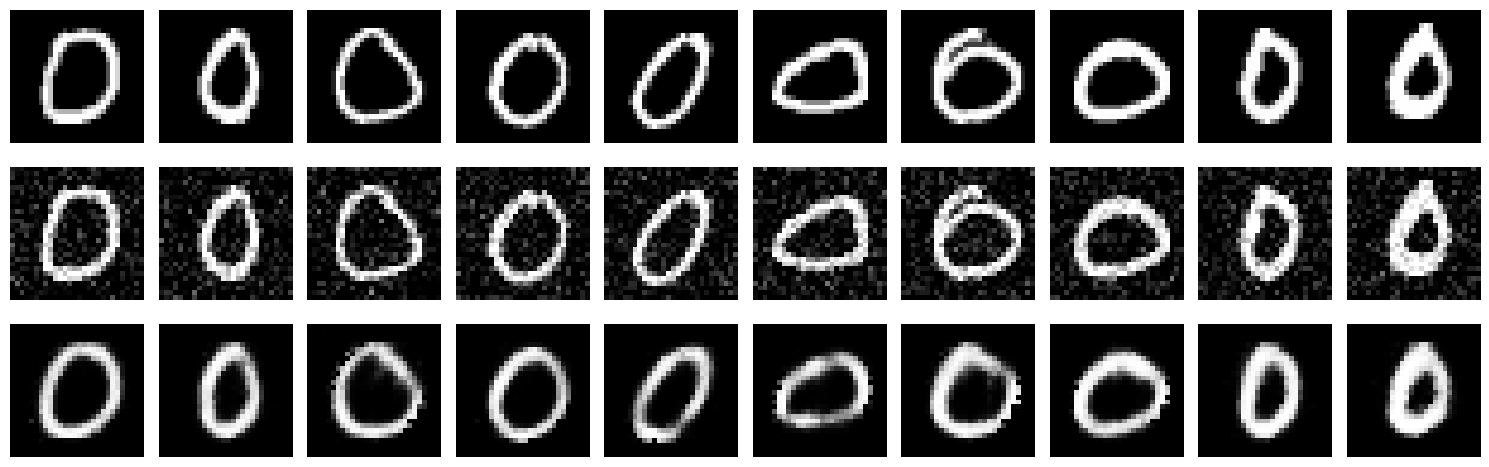

Test MSE (first 10 samples): 0.015442


In [61]:
n = 10
denoised = model.predict(x_test_noisy[:n])

fig, axes = plt.subplots(3, n, figsize=(15, 5))
for i in range(n):
    axes[0, i].imshow(x_test[i].reshape(28,28), cmap='gray')
    axes[1, i].imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    axes[2, i].imshow(denoised[i].reshape(28,28), cmap='gray')
    for ax in axes[:, i]: ax.axis('off')

axes[0,0].set_ylabel('Original')
axes[1,0].set_ylabel('Noisy')
axes[2,0].set_ylabel('Denoised')
plt.tight_layout()
plt.show()

# Print MSE on same samples
mse = np.mean((x_test[:n] - denoised) ** 2)
print(f'Test MSE (first {n} samples): {mse:.6f}')

## Summary
- Built a deep autoencoder for image denoising
- Encoder compresses 784 -> 128 -> 256 -> 784
- Model successfully removes Gaussian noise from MNIST digits
- MSE metric shows reconstruction quality